<a href="https://colab.research.google.com/github/shivamkumar359/03-rd-SEM--ASSIGNMENTS/blob/main/ML/WEEK_2_ASSIGNMENT_1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Model Test Accuracy (50 labeled samples): 72.60%
High-confidence pseudo-labels added (Threshold >= 0.9): 1621 / 1950
Final Model Test Accuracy (Combined data):       74.80%
Absolute Performance Improvement:                +2.20%


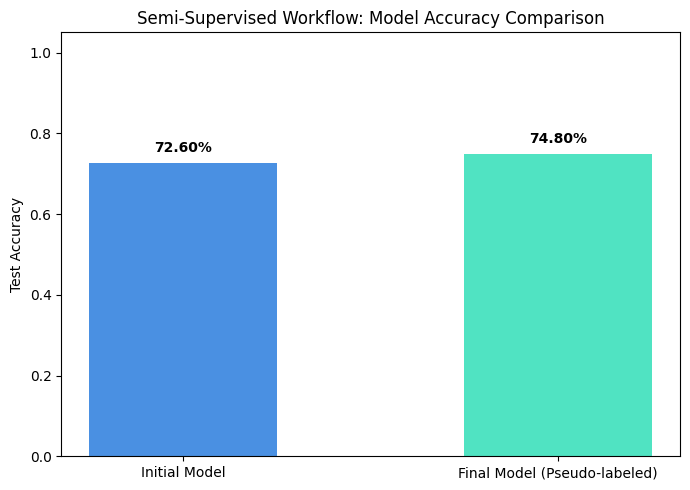

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# 1. Setup deterministic dataset
X, y = make_classification(
    n_samples=2500,
    n_features=10,
    n_informative=8,
    n_classes=2,
    weights=[0.5, 0.5],
    random_state=42
)

# Hold-out test set (500 samples)
X_pool, X_test, y_pool, y_test = train_test_split(
    X, y, test_size=500, random_state=42, stratify=y
)

# Small labeled dataset (50 samples) and large unlabeled pool (1950 samples)
X_labeled, X_unlabeled, y_labeled, _ = train_test_split(
    X_pool, y_pool, train_size=50, random_state=42, stratify=y_pool
)

# 2. Train Initial Baseline Model exclusively on small labeled dataset
initial_model = GradientBoostingClassifier(random_state=42)
initial_model.fit(X_labeled, y_labeled)

initial_preds = initial_model.predict(X_test)
initial_acc = accuracy_score(y_test, initial_preds)

# 3. Generate Pseudo-Labels for Unlabeled Data
# Thresholding based on maximum predicted class probability
CONFIDENCE_THRESHOLD = 0.90
unlabeled_probs = initial_model.predict_proba(X_unlabeled)
max_probs = np.max(unlabeled_probs, axis=1)
predicted_classes = np.argmax(unlabeled_probs, axis=1)

# Mask for high-confidence points
confident_mask = max_probs >= CONFIDENCE_THRESHOLD

# Save CSV Deliverable: pseudo_labels.csv
pseudo_df = pd.DataFrame(X_unlabeled, columns=[f"feat_{i}" for i in range(X.shape[1])])
pseudo_df["predicted_label"] = predicted_classes
pseudo_df["confidence"] = max_probs
pseudo_df["accepted_as_pseudo_label"] = confident_mask
pseudo_df.to_csv("pseudo_labels.csv", index_label="unlabeled_id")

# 4. Retrain Final Model on Combined Dataset
X_pseudo = X_unlabeled[confident_mask]
y_pseudo = predicted_classes[confident_mask]

X_combined = np.vstack([X_labeled, X_pseudo])
y_combined = np.concatenate([y_labeled, y_pseudo])

final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_combined, y_combined)

final_preds = final_model.predict(X_test)
final_acc = accuracy_score(y_test, final_preds)

# 5. Output Results & Produce Comparison Chart
print("=" * 55)
print(f"Initial Model Test Accuracy (50 labeled samples): {initial_acc * 100:.2f}%")
print(f"High-confidence pseudo-labels added (Threshold >= {CONFIDENCE_THRESHOLD}): {confident_mask.sum()} / {len(X_unlabeled)}")
print(f"Final Model Test Accuracy (Combined data):       {final_acc * 100:.2f}%")
print(f"Absolute Performance Improvement:                +{(final_acc - initial_acc) * 100:.2f}%")
print("=" * 55)

# Generate screenshot figure
plt.figure(figsize=(7, 5))
bars = plt.bar(["Initial Model", "Final Model (Pseudo-labeled)"], [initial_acc, final_acc], color=["#4A90E2", "#50E3C2"], width=0.5)
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)
plt.title("Semi-Supervised Workflow: Model Accuracy Comparison")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 0.02, f"{height * 100:.2f}%", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=300)
plt.show()